In [1]:
import numpy as np

import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import csv
import file
import sys
import os

In [2]:
path_algo = 'algo_perf/'

h2_data = np.loadtxt(path_algo + 'h2.csv', delimiter=',')
h2_mean = np.mean(h2_data, axis=0)

h23_data = np.loadtxt(path_algo + 'h23.csv', delimiter=',')
h23_mean = np.mean(h23_data, axis=0)

In [3]:
sigs = ['h2', 'h3', 'h23']
colors = ['b', 'g', 'r']
labels = [r'$\sigma_1$', r'$\sigma_2$', r'$\sigma_3$']
paths = {sig: f'data/{sig}/W_rad/Delta_1.25/v_ones/' for sig in sigs} 
data_theory = {sig: file.csv_to_dict(paths[sig] + 'unified.csv') for sig in sigs}
stats_info = {sig: file.summarize_mc_data(file.csv_to_dict(paths[sig]+'info.csv')) for sig in sigs}

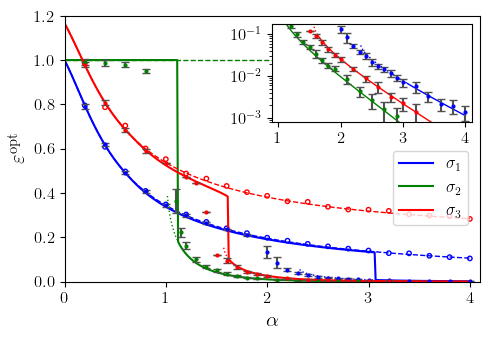

In [4]:
width, height = 5, 3.5
big, small = int(width*3), int(width*2.4)
fig, ax = plt.subplots(figsize=(width, height), tight_layout=True)

ax.tick_params(axis='both', labelsize=small)
ax.set_xlim(0, 4.1)
ax.set_ylim(0, 1.2)
ax.set_xlabel(r'$\alpha$', fontsize=big)
ax.set_ylabel(r'$\varepsilon^{\rm opt}$', fontsize=big)

inset_ax = ax.inset_axes([0.5, 0.6, 0.48, 0.37]) 
inset_ax.tick_params(axis='both', labelsize=small)
inset_ax.set_xticks([1,2,3,4])
inset_ax.set_xlim(0.9, 4.1)
inset_ax.set_ylim(0.0008,0.18)
inset_ax.set_yscale('log')

for sig, color, label in zip(sigs, colors, labels):
    # theoretical curves
    alphas = data_theory[sig]['alpha']
    mmses = data_theory[sig]['mmse']
    mmses_ = data_theory[sig]['mmse_']
    mmses_uni = data_theory[sig]['mmse_uni']
    jump = np.where(np.abs(np.diff(mmses_)) > 0.1)[0][0]+1
    ax.plot(alphas, mmses, color=color, label=label)
    ax.plot(alphas, mmses_uni, color=color, linestyle='--', linewidth=1)
    ax.plot(alphas[:jump], mmses_[:jump], color=color, linestyle=':', linewidth=1)
    inset_ax.plot(alphas[:jump], mmses_[:jump], color=color, linestyle=':', linewidth=1)
    inset_ax.plot(alphas[jump:], mmses[jump:], color=color, linewidth=1)
    # MCMC data
    ax.errorbar(stats_info[sig]['alpha'], stats_info[sig]['mmse_mean'], yerr=stats_info[sig]['mmse_std'], fmt='o', markersize=2, capsize=3, color=color, ecolor='#505050')
    inset_ax.errorbar(stats_info[sig]['alpha'], stats_info[sig]['mmse_mean'], yerr=stats_info[sig]['mmse_std'], fmt='o', markersize=2, capsize=3, color=color, ecolor='#505050')
# AMP data
alphas = np.linspace(0.2, 4, 20)
ax.scatter(alphas, h2_mean, marker='o', edgecolors='blue', facecolors='none', s=10)
ax.scatter(alphas, h23_mean, marker='o', edgecolors='red', facecolors='none', s=10)
    
ax.legend(loc="lower left", bbox_to_anchor=(0.77, 0.18), fontsize=small)

plt.savefig('fig_rad.pdf')
plt.show()